<a href="https://colab.research.google.com/github/OJB-Quantum/QC-Hardware-How-To/blob/main/Quantum_Computing_Signal_Chain_Graphic_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
!uv pip install graphviz matplotlib

Architecture 1: Room Temperature Controllers


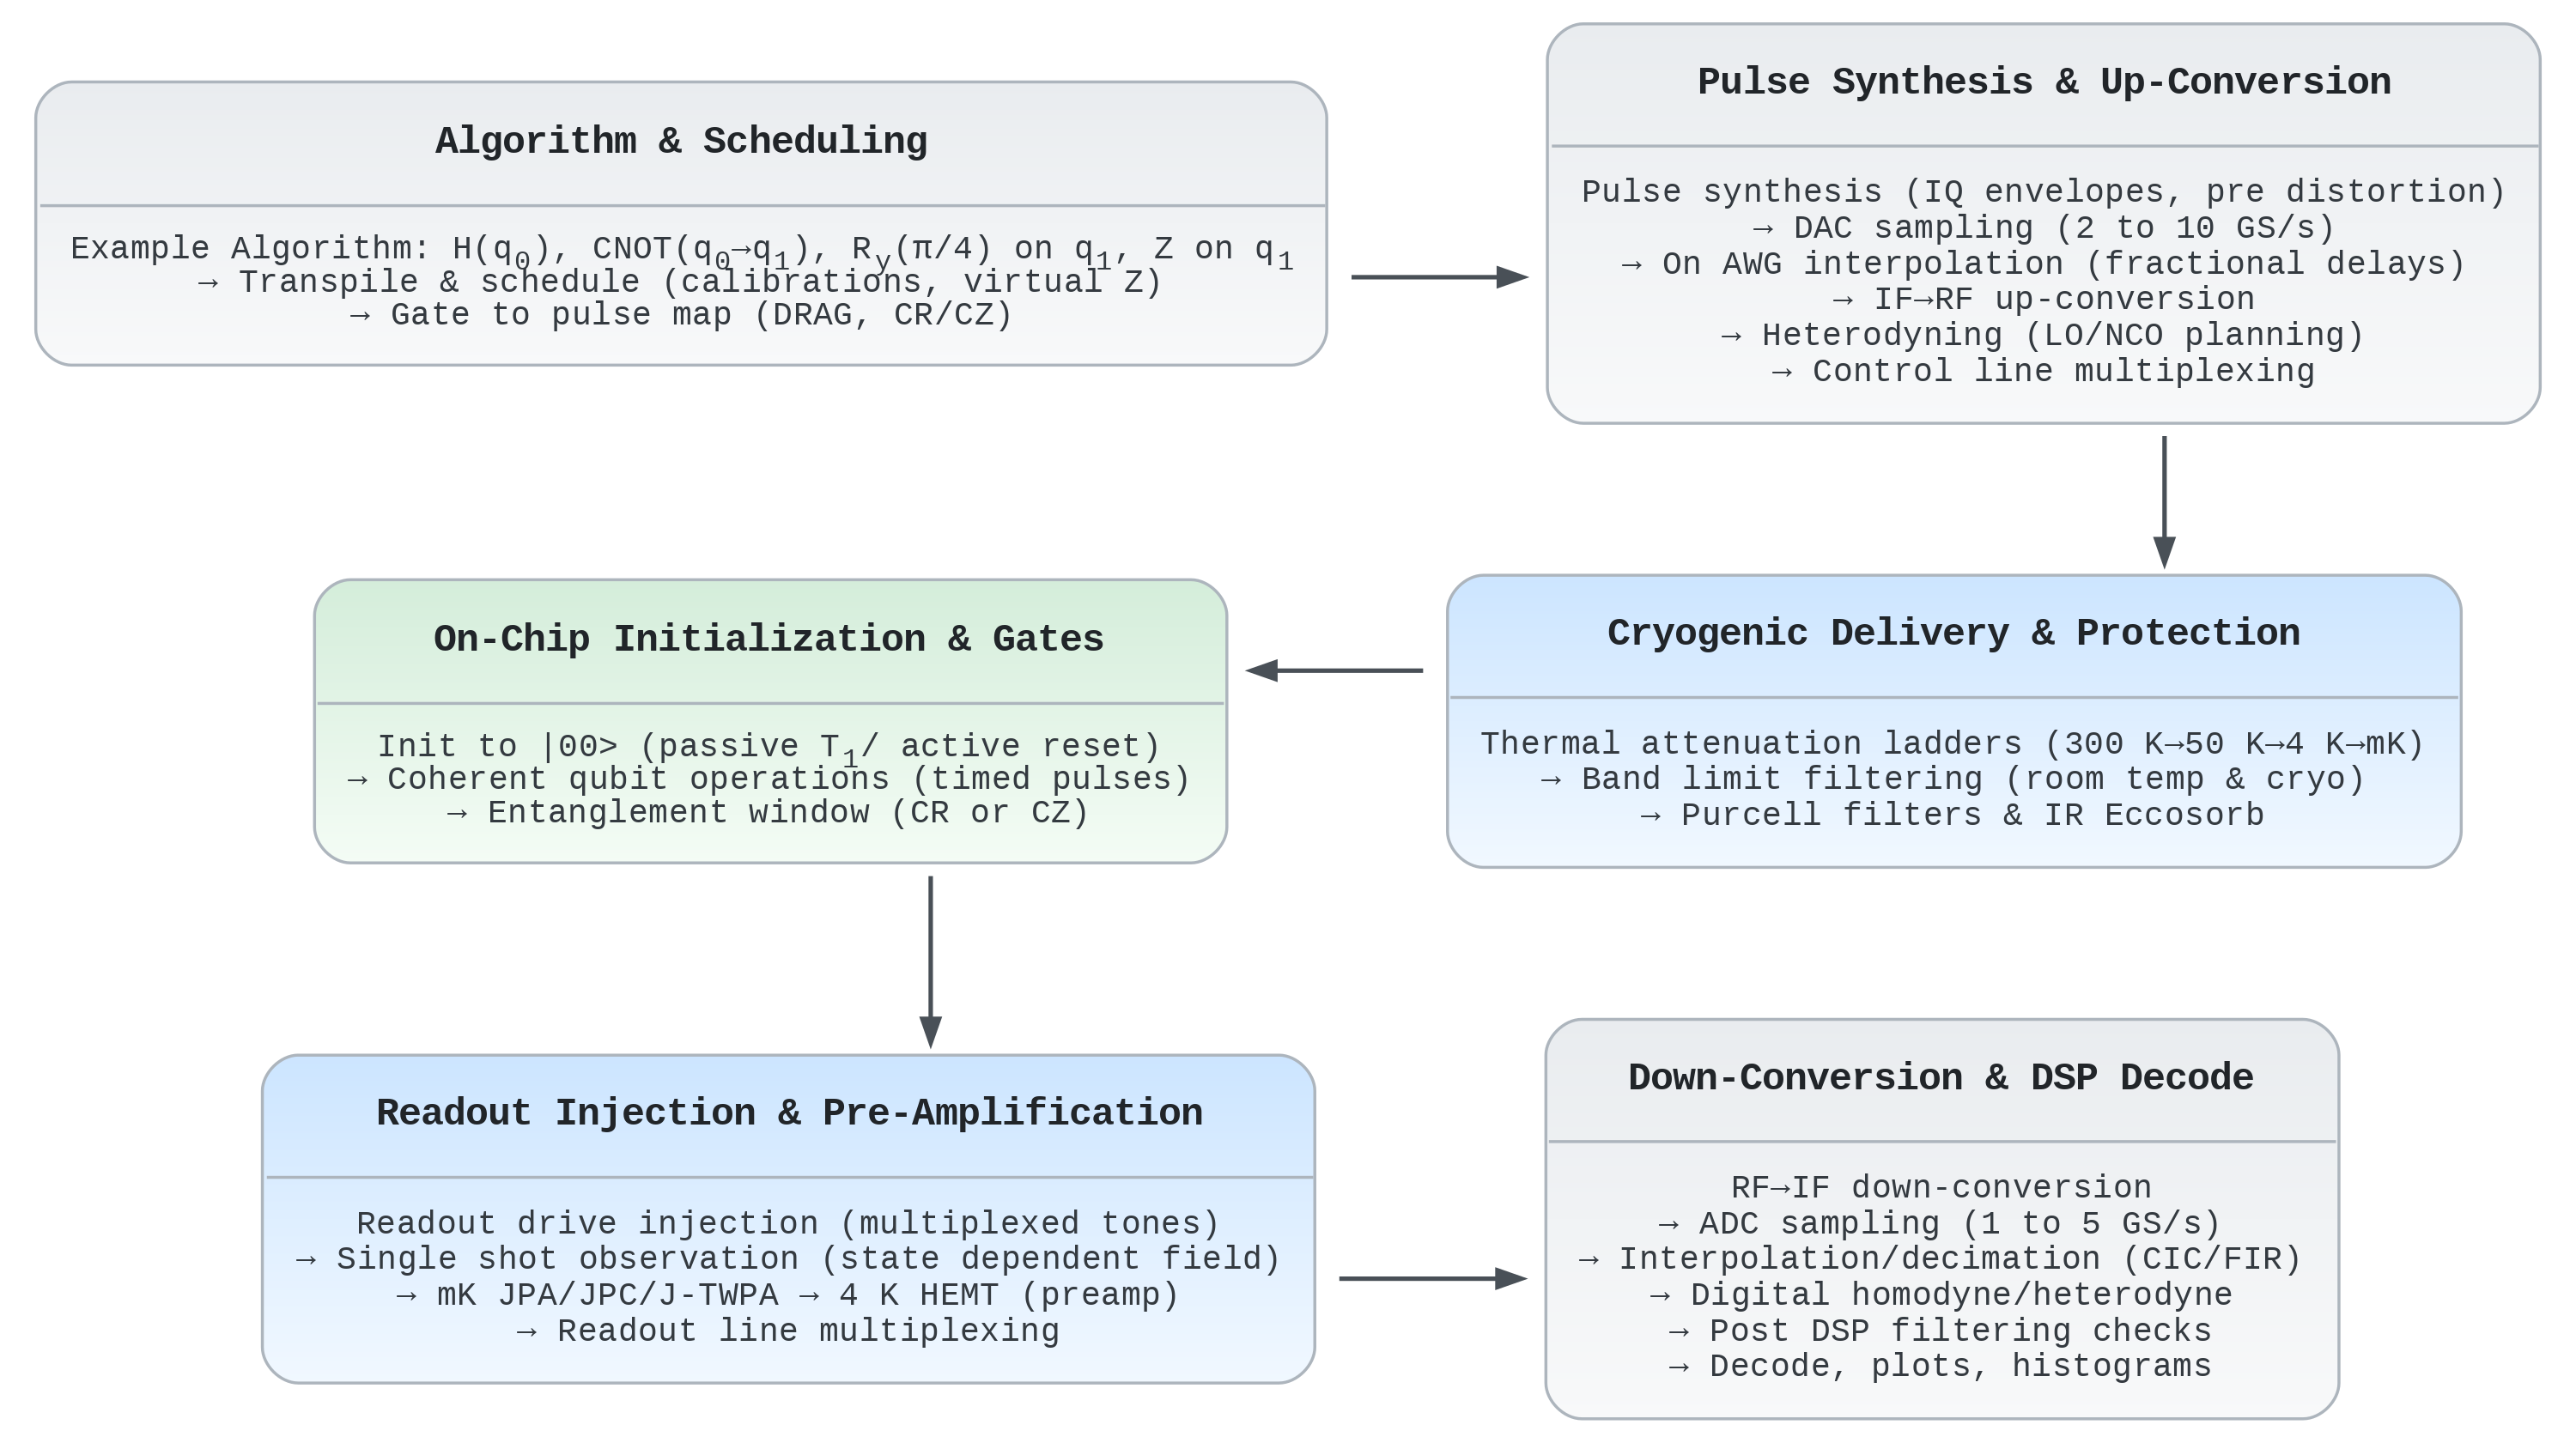


Architecture 2: Cryogenic Application Specific Integrated Circuit Controllers


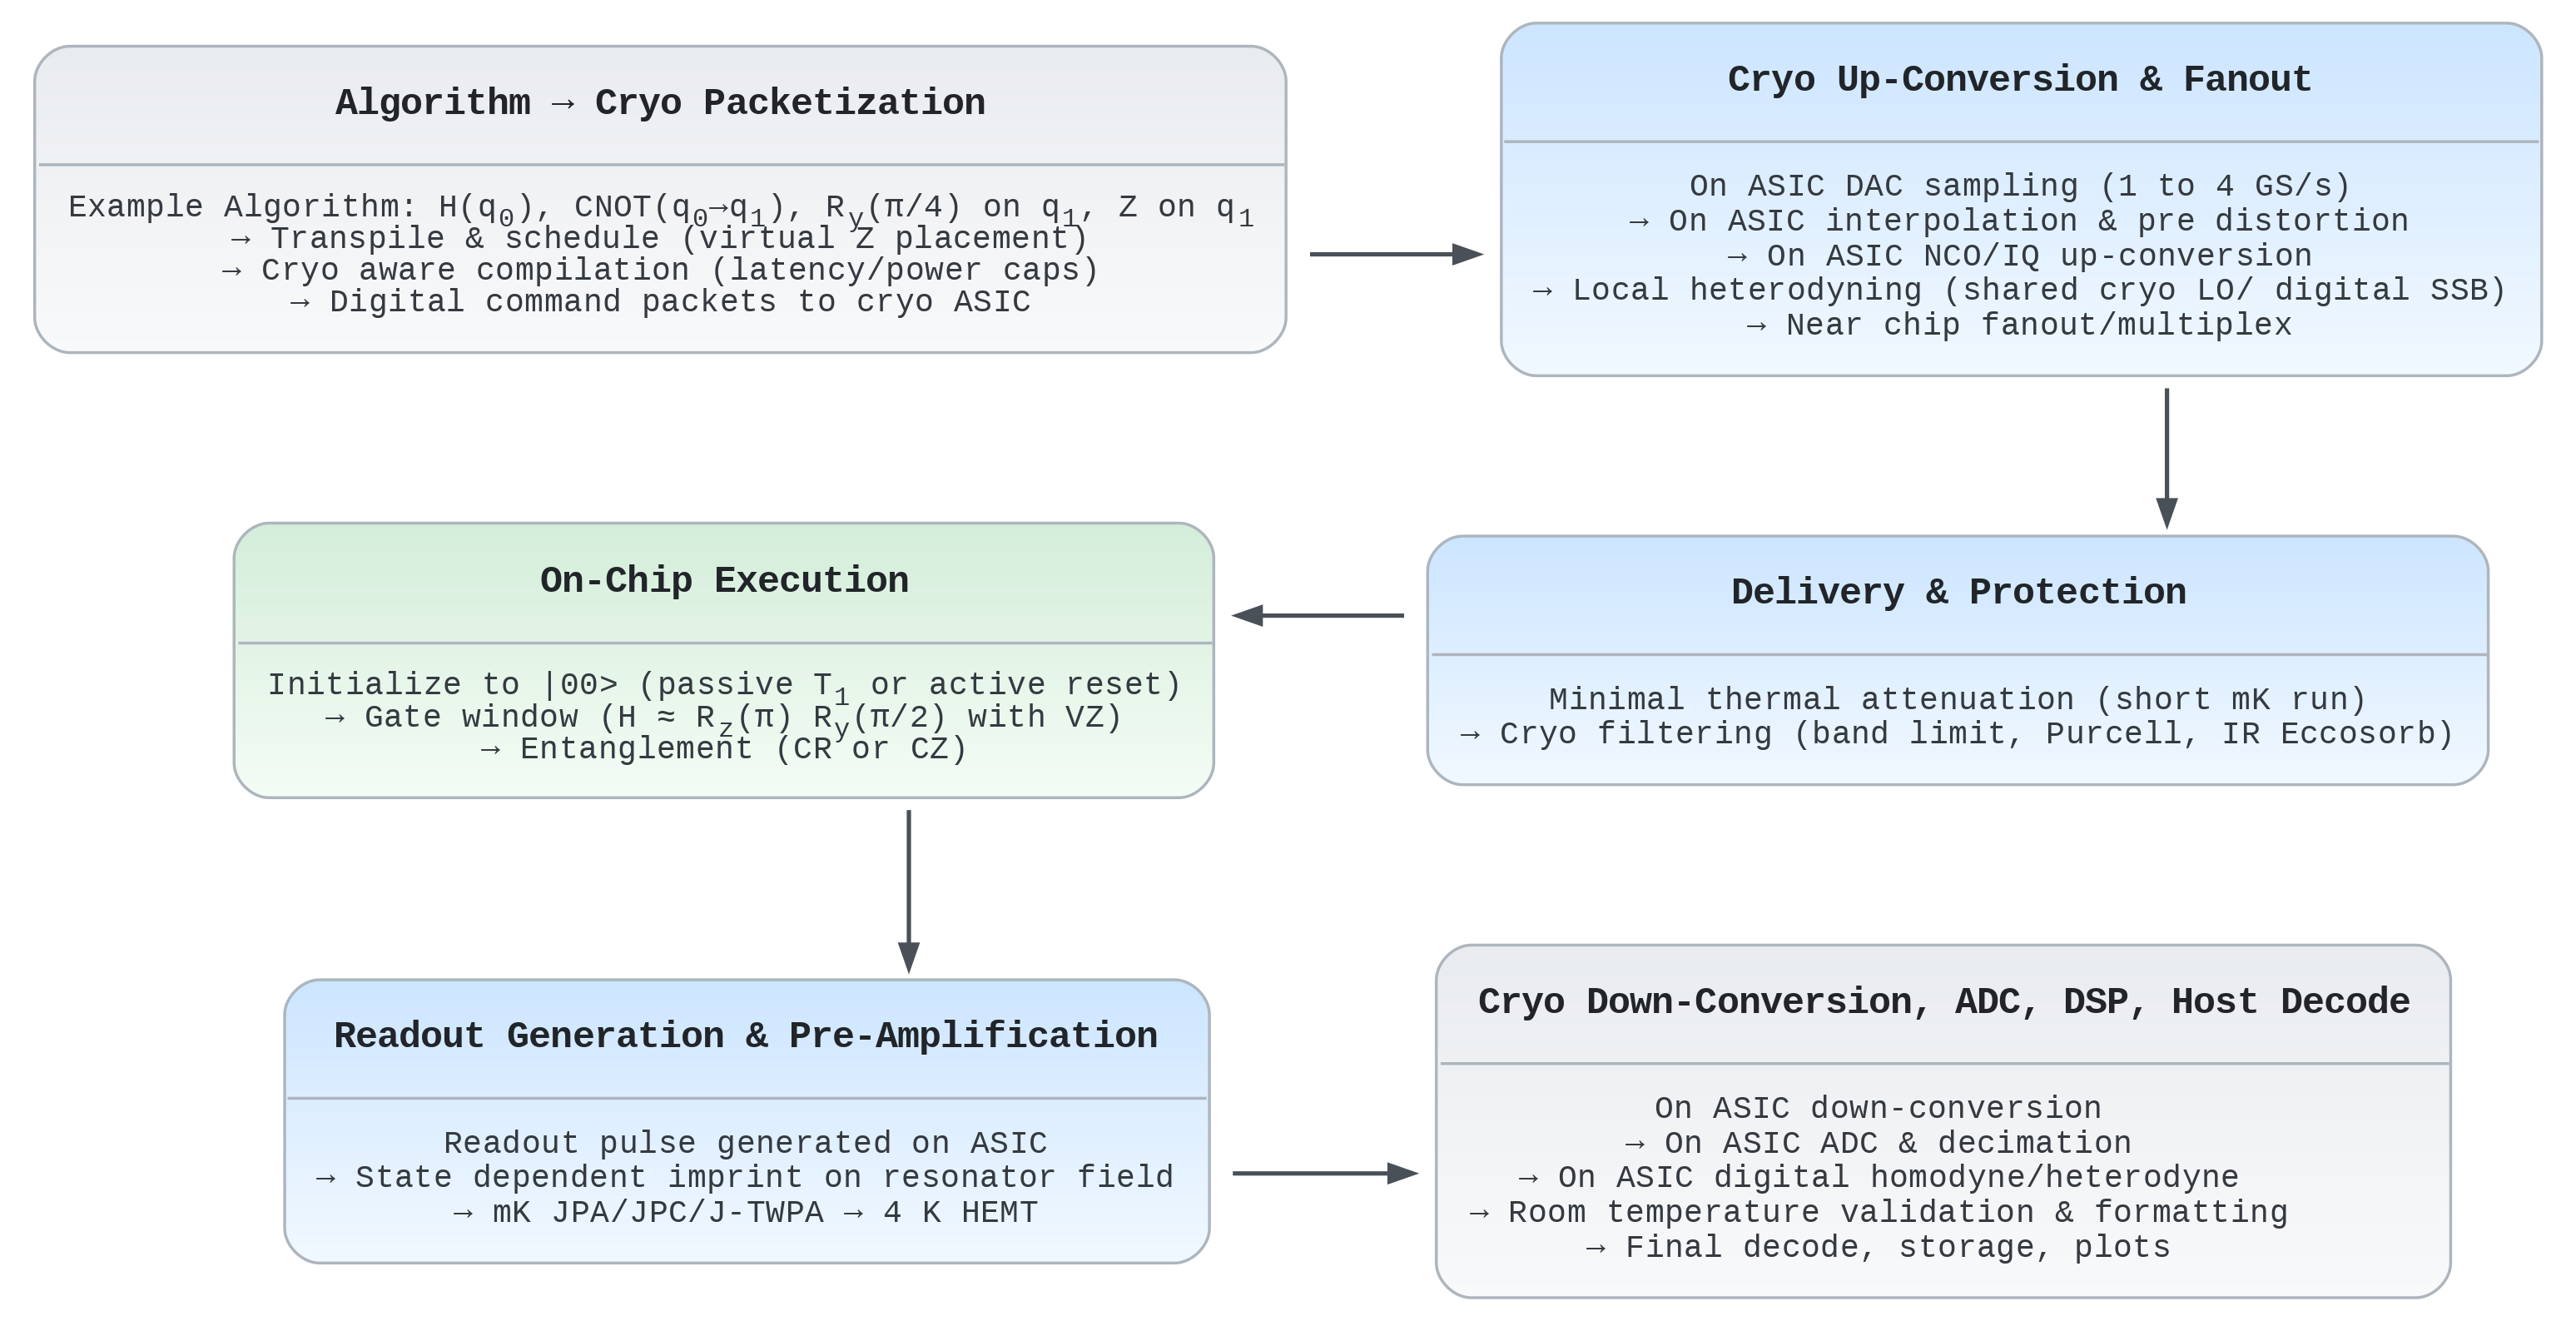

In [33]:
"""This script generates Graphviz layouts for quantum signal chains.

This script models two distinct architectural paradigms (room temperature
controllers and cryogenic application specific integrated circuits) utilizing
a serpentine topological layout.
"""

import graphviz
import matplotlib.pyplot as plt
from IPython.display import display, Image

# ---------------------------------------------------------------------------
# Control Knobs for Graph Attributes and Global Parameters
# ---------------------------------------------------------------------------
plt.rcParams['figure.dpi'] = 250
plt.rcParams['font.sans-serif'] = ['IBM Plex Sans', 'Tahoma', 'DejaVu Sans']
plt.rcParams['font.weight'] = 'normal'

# Graphviz specific typographic and rendering controls
GRAPH_DPI = "250"
FONT_NAME = "Tahoma"
FONT_WEIGHT = "normal"
RANK_DIRECTION = "TB"
NODE_SHAPE = "plaintext"
SPLINES_STYLE = "ortho"

# Modernized academic color palette for hierarchical differentiation
COLOR_ROOM_TEMP_BG = "#f8f9fa"
COLOR_ROOM_TEMP_HDR = "#e9ecef"
COLOR_CRYO_BG = "#f1f8ff"
COLOR_CRYO_HDR = "#cce5ff"
COLOR_ON_CHIP_BG = "#f4fcf5"
COLOR_ON_CHIP_HDR = "#d4edda"
COLOR_BORDER = "#adb5bd"
COLOR_EDGE = "#495057"

# Utilizing standard markup entities circumvents the missing glyph limitations
# observed in the primary typefaces while rendering the bra and ket vectors.
BRA_ENTITY = "&lt;"
KET_ENTITY = "&gt;"
RIGHT_ARROW = "&#8594;"

def create_html_label(title: str, body_lines: list[str], hdr_color: str, bdy_color: str) -> str:
    """Constructs a strictly formatted hypertext markup string for a node label.

    Args:
        title: The header text for the node.
        body_lines: A collection of strings representing operational steps.
        hdr_color: The hexadecimal color code for the header origin background.
        bdy_color: The hexadecimal color code for the body terminal background.

    Returns:
        A formatted hypertext string required by the visualization library.
    """
    body_content = "<BR/>".join(body_lines)
    html_label = (
        f'<<TABLE BORDER="1" COLOR="{COLOR_BORDER}" CELLBORDER="0" CELLSPACING="0" CELLPADDING="12" '
        f'BGCOLOR="{hdr_color}:{bdy_color}" GRADIENTANGLE="270" STYLE="ROUNDED">'
        f'<TR><TD BORDER="1" SIDES="B" COLOR="{COLOR_BORDER}">'
        f'<B><FONT FACE="{FONT_NAME}" POINT-SIZE="13" COLOR="#212529">{title}</FONT></B></TD></TR>'
        f'<TR><TD ALIGN="LEFT" CELLPADDING="10"><FONT FACE="{FONT_NAME}" POINT-SIZE="11" COLOR="#343a40">{body_content}</FONT></TD></TR>'
        f'</TABLE>>'
    )
    return html_label

def apply_serpentine_constraints(graph: graphviz.Digraph, nodes: list[str]) -> None:
    """Imposes an invisible grid layout to enforce a serpentine data flow.

    The algorithm groups nodes into a symmetrical matrix, which decouples the physical
    placement of the nodes from the visible data flow edges.

    Args:
        graph: The directed graph instance undergoing manipulation.
        nodes: A sequence of six node identifiers representing the chain.
    """
    n1, n2, n3, n4, n5, n6 = nodes

    with graph.subgraph() as row1:
        row1.attr(rank="same")
        row1.node(n1)
        row1.node(n2)
    with graph.subgraph() as row2:
        row2.attr(rank="same")
        row2.node(n4)
        row2.node(n3)
    with graph.subgraph() as row3:
        row3.attr(rank="same")
        row3.node(n5)
        row3.node(n6)

    graph.edge(n1, n4, style="invis")
    graph.edge(n4, n5, style="invis")
    graph.edge(n2, n3, style="invis")
    graph.edge(n3, n6, style="invis")
    graph.edge(n1, n2, style="invis")
    graph.edge(n4, n3, style="invis")
    graph.edge(n5, n6, style="invis")

def render_room_temperature_chain() -> bytes:
    """Builds the signal chain graph for room temperature controllers.

    Returns:
        A byte sequence representing the rendered portable network graphics image.
    """
    graph = graphviz.Digraph(
        name="RoomTempControllers",
        graph_attr={
            "dpi": GRAPH_DPI,
            "rankdir": RANK_DIRECTION,
            "splines": SPLINES_STYLE,
            "nodesep": "0.8",
            "ranksep": "0.6"
        },
        node_attr={"shape": NODE_SHAPE, "fontname": FONT_NAME},
        edge_attr={
            "fontname": FONT_NAME,
            "color": COLOR_EDGE,
            "penwidth": "1.5",
            "arrowsize": "0.8"
        }
    )

    lbl_alg = create_html_label(
        "Algorithm &amp; Scheduling",
        [
            f"Example Algorithm: H(q<SUB>0</SUB>), CNOT(q<SUB>0</SUB>{RIGHT_ARROW}q<SUB>1</SUB>), R<SUB>y</SUB>(&#960;/4) on q<SUB>1</SUB>, Z on q<SUB>1</SUB>",
            f"{RIGHT_ARROW} Transpile &amp; schedule (calibrations, virtual Z)",
            f"{RIGHT_ARROW} Gate to pulse map (DRAG, CR/CZ)"
        ], COLOR_ROOM_TEMP_HDR, COLOR_ROOM_TEMP_BG)
    graph.node("Alg", label=lbl_alg)

    lbl_pulse = create_html_label(
        "Pulse Synthesis &amp; Up-Conversion",
        [
            "Pulse synthesis (IQ envelopes, pre distortion)",
            f"{RIGHT_ARROW} DAC sampling (2 to 10 GS/s)",
            f"{RIGHT_ARROW} On AWG interpolation (fractional delays)",
            f"{RIGHT_ARROW} IF{RIGHT_ARROW}RF up-conversion",
            f"{RIGHT_ARROW} Heterodyning (LO/NCO planning)",
            f"{RIGHT_ARROW} Control line multiplexing"
        ], COLOR_ROOM_TEMP_HDR, COLOR_ROOM_TEMP_BG)
    graph.node("Pulse", label=lbl_pulse)

    lbl_cryo = create_html_label(
        "Cryogenic Delivery &amp; Protection",
        [
            f"Thermal attenuation ladders (300 K{RIGHT_ARROW}50 K{RIGHT_ARROW}4 K{RIGHT_ARROW}mK)",
            f"{RIGHT_ARROW} Band limit filtering (room temp &amp; cryo)",
            f"{RIGHT_ARROW} Purcell filters &amp; IR Eccosorb"
        ], COLOR_CRYO_HDR, COLOR_CRYO_BG)
    graph.node("Cryo", label=lbl_cryo)

    lbl_chip = create_html_label(
        "On-Chip Initialization &amp; Gates",
        [
            f"Init to |00{KET_ENTITY} (passive T<SUB>1</SUB>/ active reset)",
            f"{RIGHT_ARROW} Coherent qubit operations (timed pulses)",
            f"{RIGHT_ARROW} Entanglement window (CR or CZ)"
        ], COLOR_ON_CHIP_HDR, COLOR_ON_CHIP_BG)
    graph.node("Chip", label=lbl_chip)

    lbl_readout = create_html_label(
        "Readout Injection &amp; Pre-Amplification",
        [
            "Readout drive injection (multiplexed tones)",
            f"{RIGHT_ARROW} Single shot observation (state dependent field)",
            f"{RIGHT_ARROW} mK JPA/JPC/J-TWPA {RIGHT_ARROW} 4 K HEMT (preamp)",
            f"{RIGHT_ARROW} Readout line multiplexing"
        ], COLOR_CRYO_HDR, COLOR_CRYO_BG)
    graph.node("Readout", label=lbl_readout)

    lbl_downconv = create_html_label(
        "Down-Conversion &amp; DSP Decode",
        [
            f"RF{RIGHT_ARROW}IF down-conversion",
            f"{RIGHT_ARROW} ADC sampling (1 to 5 GS/s)",
            f"{RIGHT_ARROW} Interpolation/decimation (CIC/FIR)",
            f"{RIGHT_ARROW} Digital homodyne/heterodyne",
            f"{RIGHT_ARROW} Post DSP filtering checks",
            f"{RIGHT_ARROW} Decode, plots, histograms"
        ], COLOR_ROOM_TEMP_HDR, COLOR_ROOM_TEMP_BG)
    graph.node("DownConv", label=lbl_downconv)

    apply_serpentine_constraints(graph, ["Alg", "Pulse", "Cryo", "Chip", "Readout", "DownConv"])

    graph.edge("Alg", "Pulse", constraint="false")
    graph.edge("Pulse", "Cryo", constraint="false")
    graph.edge("Cryo", "Chip", constraint="false")
    graph.edge("Chip", "Readout", constraint="false")
    graph.edge("Readout", "DownConv", constraint="false")

    return graph.pipe(format="png")

def render_cryo_asic_chain() -> bytes:
    """Builds the signal chain graph for cryogenic application specific integrated circuits.

    Returns:
        A byte sequence representing the rendered portable network graphics image.
    """
    graph = graphviz.Digraph(
        name="CryoASICControllers",
        graph_attr={
            "dpi": GRAPH_DPI,
            "rankdir": RANK_DIRECTION,
            "splines": SPLINES_STYLE,
            "nodesep": "0.8",
            "ranksep": "0.6"
        },
        node_attr={"shape": NODE_SHAPE, "fontname": FONT_NAME},
        edge_attr={
            "fontname": FONT_NAME,
            "color": COLOR_EDGE,
            "penwidth": "1.5",
            "arrowsize": "0.8"
        }
    )

    lbl_alg = create_html_label(
        f"Algorithm {RIGHT_ARROW} Cryo Packetization",
        [
            f"Example Algorithm: H(q<SUB>0</SUB>), CNOT(q<SUB>0</SUB>{RIGHT_ARROW}q<SUB>1</SUB>), R<SUB>y</SUB>(&#960;/4) on q<SUB>1</SUB>, Z on q<SUB>1</SUB>",
            f"{RIGHT_ARROW} Transpile &amp; schedule (virtual Z placement)",
            f"{RIGHT_ARROW} Cryo aware compilation (latency/power caps)",
            f"{RIGHT_ARROW} Digital command packets to cryo ASIC"
        ], COLOR_ROOM_TEMP_HDR, COLOR_ROOM_TEMP_BG)
    graph.node("Alg", label=lbl_alg)

    lbl_upconv = create_html_label(
        "Cryo Up-Conversion &amp; Fanout",
        [
            "On ASIC DAC sampling (1 to 4 GS/s)",
            f"{RIGHT_ARROW} On ASIC interpolation &amp; pre distortion",
            f"{RIGHT_ARROW} On ASIC NCO/IQ up-conversion",
            f"{RIGHT_ARROW} Local heterodyning (shared cryo LO/ digital SSB)",
            f"{RIGHT_ARROW} Near chip fanout/multiplex"
        ], COLOR_CRYO_HDR, COLOR_CRYO_BG)
    graph.node("UpConv", label=lbl_upconv)

    lbl_delivery = create_html_label(
        "Delivery &amp; Protection",
        [
            "Minimal thermal attenuation (short mK run)",
            f"{RIGHT_ARROW} Cryo filtering (band limit, Purcell, IR Eccosorb)"
        ], COLOR_CRYO_HDR, COLOR_CRYO_BG)
    graph.node("Delivery", label=lbl_delivery)

    lbl_chip = create_html_label(
        "On-Chip Execution",
        [
            f"Initialize to |00{KET_ENTITY} (passive T<SUB>1</SUB> or active reset)",
            f"{RIGHT_ARROW} Gate window (H &#8776; R<SUB>z</SUB>(&#960;) R<SUB>y</SUB>(&#960;/2) with VZ)",
            f"{RIGHT_ARROW} Entanglement (CR or CZ)"
        ], COLOR_ON_CHIP_HDR, COLOR_ON_CHIP_BG)
    graph.node("Chip", label=lbl_chip)

    lbl_readout = create_html_label(
        "Readout Generation &amp; Pre-Amplification",
        [
            "Readout pulse generated on ASIC",
            f"{RIGHT_ARROW} State dependent imprint on resonator field",
            f"{RIGHT_ARROW} mK JPA/JPC/J-TWPA {RIGHT_ARROW} 4 K HEMT"
        ], COLOR_CRYO_HDR, COLOR_CRYO_BG)
    graph.node("Readout", label=lbl_readout)

    lbl_downconv = create_html_label(
        "Cryo Down-Conversion, ADC, DSP, Host Decode",
        [
            "On ASIC down-conversion",
            f"{RIGHT_ARROW} On ASIC ADC &amp; decimation",
            f"{RIGHT_ARROW} On ASIC digital homodyne/heterodyne",
            f"{RIGHT_ARROW} Room temperature validation &amp; formatting",
            f"{RIGHT_ARROW} Final decode, storage, plots"
        ], COLOR_ROOM_TEMP_HDR, COLOR_ROOM_TEMP_BG)
    graph.node("DownConv", label=lbl_downconv)

    apply_serpentine_constraints(graph, ["Alg", "UpConv", "Delivery", "Chip", "Readout", "DownConv"])

    graph.edge("Alg", "UpConv", constraint="false")
    graph.edge("UpConv", "Delivery", constraint="false")
    graph.edge("Delivery", "Chip", constraint="false")
    graph.edge("Chip", "Readout", constraint="false")
    graph.edge("Readout", "DownConv", constraint="false")

    return graph.pipe(format="png")

def main() -> None:
    """Executes the rendering functions and displays the graphical output."""
    png_data_room = render_room_temperature_chain()
    png_data_asic = render_cryo_asic_chain()

    print("Architecture 1: Room Temperature Controllers")
    display(Image(data=png_data_room))

    print("\nArchitecture 2: Cryogenic Application Specific Integrated Circuit Controllers")
    display(Image(data=png_data_asic))

if __name__ == "__main__":
    main()